# 01_data_eda

In [1]:
from datasets import load_dataset

ds = load_dataset("cfilt/iitb-english-hindi")

README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

d:\Dl projects\mt-en-hi\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kunja\.cache\huggingface\hub\datasets--cfilt--iitb-english-hindi. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

d:\Dl projects\mt-en-hi\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kunja\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  190MB            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  500kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

In [12]:
ds

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})

In [13]:
import pandas as pd
train_df = pd.DataFrame(ds["train"]["translation"])
train_df.head()

,en,hi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...


In [14]:
test_df = pd.DataFrame(ds["test"]["translation"])
val_df = pd.DataFrame(ds["validation"]["translation"])

In [15]:
len(train_df), len(test_df), len(val_df)

(1659083, 2507, 520)

In [16]:
print(train_df.isnull().sum())

en    0
hi    0
dtype: int64


In [19]:
train_df["en"].apply(lambda x: len(x.split())).max(), train_df["en"].apply(lambda x: len(x.split())).min()

(np.int64(1917), np.int64(0))

<Axes: >

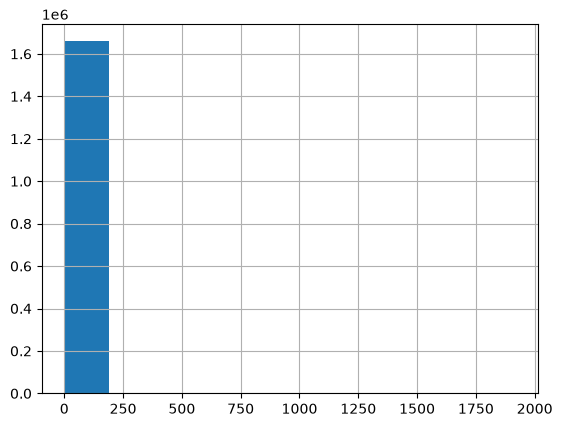

In [ ]:
train_df["en"].apply(lambda x: len(x.split())).hist(bins=10)

In [21]:
train_df[train_df["en"].apply(lambda x: len(x.split()) == 0)]

,en,hi
439613,,को सीखने के लिए खुला रख पाएँ हो सकता है हम अपन...
446040,,सर घुमाने के लिए जब भी कोई स्वर बदलता है-और हम...
481093,,दरअसल वो गणना कर रहे होते हैं तब
497989,,"शिशु सुनते हैं, जब"
511794,,"तक पाहुचने के लिए, सत्य"
...,...,...
1089970,,
1090247,,
1090397,,
1130790,,"हड़ताल करने, बहिष्कार करने, धरना करने, और अन्य..."


<Axes: >

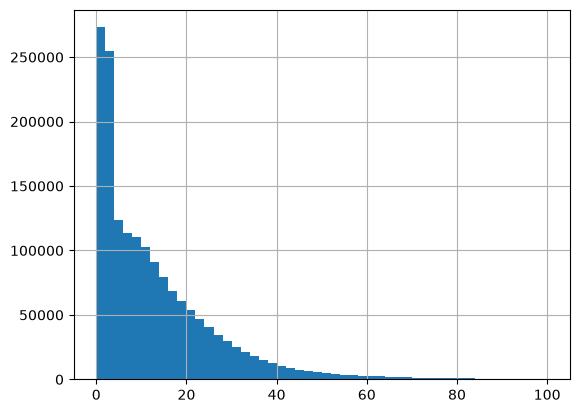

In [23]:
train_df["en"].apply(lambda x: len(x.split())).hist(bins=50, range=(0, 100))

In [24]:
train_df["en"].apply(lambda x: len(x.split())).describe(percentiles=[.5, .9, .95, .99])

count    1.659083e+06
mean     1.303791e+01
std      1.516731e+01
min      0.000000e+00
50%      9.000000e+00
90%      3.000000e+01
95%      4.000000e+01
99%      6.800000e+01
max      1.917000e+03
Name: en, dtype: float64

<Axes: >

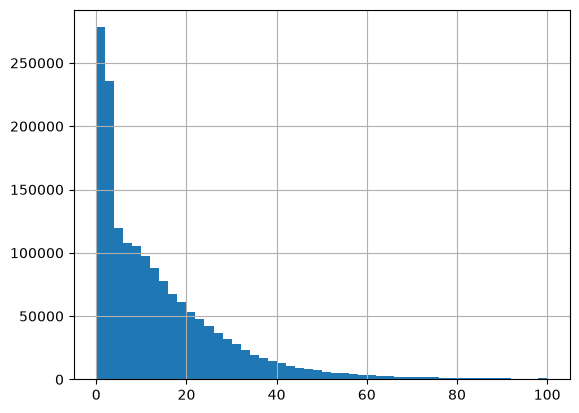

In [25]:
train_df["hi"].apply(lambda x: len(x.split())).hist(bins=50, range=(0, 100))

In [26]:
train_df["hi"].apply(lambda x: len(x.split())).describe(percentiles=[.5, .9, .95, .99])

count    1.659083e+06
mean     1.405483e+01
std      1.650311e+01
min      0.000000e+00
50%      9.000000e+00
90%      3.300000e+01
95%      4.400000e+01
99%      7.600000e+01
max      1.380000e+03
Name: hi, dtype: float64

In [27]:
print(train_df.duplicated(subset=["en", "hi"]).sum())

219386


In [28]:
train_df = train_df.drop_duplicates(subset=["en", "hi"]).reset_index(drop=True)
print(len(train_df))

1439697


In [29]:
train_pairs = set(zip(train_df["en"], train_df["hi"]))
test_pairs = set(zip(test_df["en"], test_df["hi"]))
overlap_pairs = train_pairs.intersection(test_pairs)
print(f"Number of overlapping pairs between train and test: {len(overlap_pairs)}")

Number of overlapping pairs between train and test: 0


In [31]:
def is_valid_length(row):
    en_len = len(row["en"].split())
    hi_len = len(row["hi"].split())
    return 1 <= en_len <= 64 and 1 <= hi_len <= 80

train_df = train_df[train_df.apply(is_valid_length, axis=1)].reset_index(drop=True)
val_df = val_df[val_df.apply(is_valid_length, axis=1)].reset_index(drop=True)
test_df = test_df[test_df.apply(is_valid_length, axis=1)].reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 1413872
Val: 520
Test: 2505


In [34]:
from datasets import Dataset, DatasetDict

dataset_filtered = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

dataset_filtered.save_to_disk("../data/processed/iitb_filtered")

Saving the dataset (0/1 shards):   0%|          | 0/1413872 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/520 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2505 [00:00<?, ? examples/s]